In [4]:
import rebound
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# SPEED IS ROUGHLY  100 tu / 1s 
def initialize_simulation(e, z, z_dot, t):
    '''
    Returns rebound simulation for Sitnikov problem given initial conditions.
    sim.integrator = ias15 by default, so it can handle any timescale
    and deal with high-precision long-term integration
    '''
    # Compute t mod 2pi
    k = np.floor(t/(2*np.pi))
    t2 = t - k*2*np.pi

    a = 1/2
    m = 1/2
    x_ph = a*(1-e)
    v_ph = 1/2*np.sqrt((1+e)/(1-e))

    # Prepare simulation and set primaries
    # to initial position at t/t2
    sim = rebound.Simulation()
    sim.add(m = 1/2, x = -x_ph, y = 0, z = 0,
                    vx = 0, vy = -v_ph, vz = 0)
    sim.add(m = 1/2, x = x_ph, y = 0, z = 0,
                    vx = 0, vy = v_ph, vz = 0)
    sim.integrate(t2)

    # we set time to t manuallly
    sim.t = t

    sim.add(m = 0, x = 0, y = 0, z = z,
                   vx = 0, vy = 0, vz = z_dot)
    
    return sim

In [6]:
# Function to diagnose orbits
def plot_position_sitnikov(sim, T, dt):
    '''
    Plots a 1D plot of position over time given the simulation variable
    time range from 0 to dt*np.floor(T/dt)
    '''
    sim2 = sim.copy()
    N = int(np.floor(T/dt)) + 1 # for each multiple dt*i \leq T
    z_arr = np.zeros((N,))
    for i in range(N):
        z_arr[i] = sim2.particles[2].z
        sim2.integrate(sim2.t + dt)
    
    plt.plot(np.arange(N)*dt, z_arr)
    plt.show()

In [7]:
sim = initialize_simulation(e = 0.5 + 0.1*np.random.random(), z = 0, 
                            z_dot = 0.5 + 0.1*np.random.random(), t = 2*np.pi* np.random.random())

T = 100
N = 20000

for i in range(N):
    sim.integrate(T/N*(i+1))

In [26]:
from scipy.optimize import brentq

def phi(e, v, t):
    '''
    Pair of return velocity, time, when it exists.
    Note v has to be a non-negative velocity.

    When the points don't return in less than max_time = 1000,
    we simply return (None, None)
    '''

    if v<0:
        raise ValueError(f"Velocity must be non-negative, got v = {v}")

    sim = initialize_simulation(e=e, z=0, z_dot=v, t=t)
    
    # Coarse search
    r_min = 0.5*(1-e)
    # We ensure dt < T_ret/2, to avoid skipping two roots z = 0
    # Experimentally, this is confirmed
    dt = min(0.1, 2*v*r_min**2) 
    max_time = 1000
    t_start = t
    
    while sim.t < t_start + max_time:
        z_prev = sim.particles[2].z
        sim_prev = sim.copy()

        sim.integrate(sim.t + dt)
        z_curr = sim.particles[2].z
        
        if z_prev > 0 and z_curr <= 0:
            
            # The crossing time must be between t1 and t1 + dt 
            t1 = sim_prev.t

            # Refine with brentq
            def z_at_time(tau):
                s = sim_prev.copy()
                s.integrate(tau)
                return s.particles[2].z
            
            t_cross = brentq(z_at_time, t1, t1 + dt, xtol = 1e-18, rtol = 1e-15)
            sim_final = sim_prev.copy()
            sim_final.integrate(t_cross)
            v_cross = sim_final.particles[2].vz
            
            return (-v_cross, t_cross)
    
    return (None, None)

In [24]:
# The speed for medium velocities like 0.1 - 0.5 is around 0.1s/call
N_samp = 10
for _ in range(N_samp):
    e0 = 0.2 + 0.1*np.random.random()
    v0 = 0.5*np.random.random()
    t0 = 2*np.pi*np.random.random()
    v,t  = phi(e = e0, v =  v0, t = t0)
    print(v, t)



dt =  0.07395312103671779
0.28411112657725307 3.82618350364872
dt =  0.07897004629531021
0.24986918962597027 3.1318462950110177
dt =  0.037621210005215296
0.14217344579024271 6.766952342075224
dt =  0.054362656636011364
0.1822554234300143 6.83712327666538
dt =  0.003631801042169698
0.00978192420090954 1.3973882769570134
dt =  0.07583195009929482
0.2609342141762081 3.4366052588771367
dt =  0.052606701025194685
0.2001525051063679 4.12957816921362
dt =  0.1
0.4019588742419479 3.602865100693906
dt =  0.011182016928289502
0.03296901211861377 1.3934832881360582
dt =  0.013069959935928601
0.057453668274805116 5.267597799110304


In the case below, for 0.001-0.005 velocities, it takes up to 20s to do a single phi

In [10]:
# The speed for medium velocities like 0.1 - 0.5 is around 0.1s/call
N_samp = 10
for _ in range(N_samp):
    e0 = 0.2 + 0.1*np.random.random()
    v0 = 0.005*np.random.random()
    t0 = 2*np.pi*np.random.random()
    v,t  = phi(e = e0, v =  v0, t = t0)
    print(v, t)


dt =  0.0001599847157200271
0.0006901189909436421 5.27497442005327
dt =  2.5398222875620276e-05
9.448834162501709e-05 5.285602270292817
dt =  0.00033320908813166874
0.0009563039129917156 2.9431701810245365
dt =  0.0012707172712870403
0.005398071203365635 4.792879670980739
dt =  0.001156845343409484
0.004130351129576773 6.556024434494704
dt =  0.00024683164996291344
0.0008576703230431824 3.611928760298698
dt =  0.0012641975503099733
0.005213073219164449 5.030666674683553
dt =  0.0006212510085323433
0.0018765414426300871 3.171529862231356
dt =  0.0011352725626795487
0.0040068772727620446 3.6113068430819495
dt =  0.0009426238573516821
0.0035633389556603647 4.119813098525563


We have checked that phi has reasonable compute times for quick returns.
We still have to check:
- Does the output make sense? Yes
- Does it not skip any returns even for small v? Yes
- How long does it take when return doesn't happen? It seems around 10-15s

Note it can take far longer to compute for small values of v

Initial conditions: e = 0.31, v = 1.41, t = 3.30
Final conditions:             v = 1.53, t = 8.43


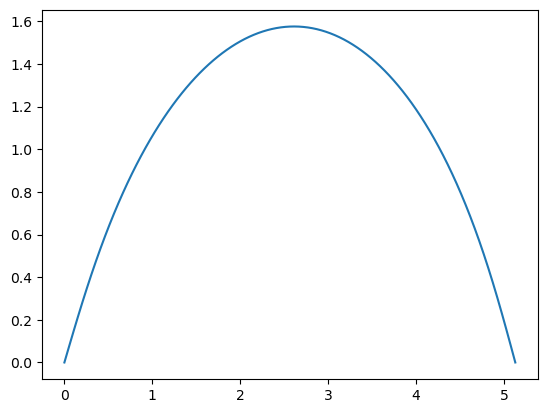

The final z position is : 4.873586999258577e-10
The final velocity error is : 4.928146779548115e-11


In [27]:
v = 1.41
t = 3.30
e = 0.31

print("Initial conditions: e = {0:.2f}, v = {1:.2f}, t = {2:.2f}".format(e,v,t))

v1, t1 = phi(e,v,t)
if v1 == None or t1 == None:
    raise ValueError("No return in less than t_max")

print("Final conditions:             v = {0:.2f}, t = {1:.2f}".format(v1, t1))

sim = initialize_simulation(e, 0, v, t)
T = t1-t
plot_position_sitnikov(sim, T, (T/100))

sim = initialize_simulation(e, 0, v, t)
sim.integrate(t1)
print("The final z position is :",  np.abs(sim.particles[2].z))
print("The final velocity error is :", np.abs(v1 + sim.particles[2].vz))


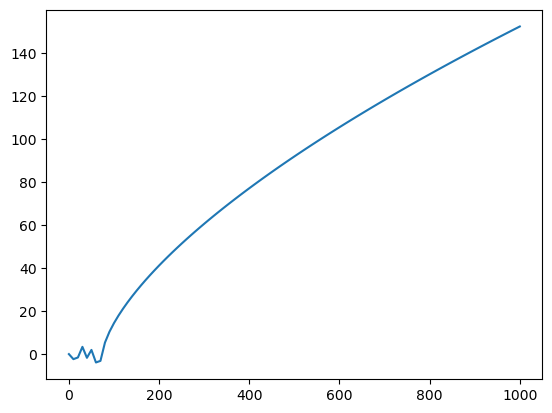

In [12]:
sim = initialize_simulation(e, 0, v, t)
plot_position_sitnikov(sim, 1000, 10)

In [13]:
v = 2.9
t = 3.30
e = 0.31

print("Initial conditions: e = {0:.2f}, v = {1:.2f}, t = {2:.2f}".format(e,v,t))

v1, t1 = phi(e,v,t)
if v1 == None or t1 == None:
    raise ValueError("No return in less than t_max")

print("Final conditions:             v = {0:.2f}, t = {1:.2f}".format(v1, t1))

sim = initialize_simulation(e, 0, v, t)
T = t1-t
plot_position_sitnikov(sim, T, (T/100))

sim = initialize_simulation(e, 0, v, t)
sim.integrate(t1)
print("The final z position is :",  np.abs(sim.particles[2].z))
print("The final velocity error is :", np.abs(v1 + sim.particles[2].vz))


Initial conditions: e = 0.31, v = 2.90, t = 3.30
dt =  0.1


ValueError: No return in less than t_max